In [1]:
import os
import json
from ast import literal_eval
from datetime import datetime, timedelta

import pandas as pd

import numpy as np
from IPython.display import clear_output

from python_utilities.db_connection import DbConnection


In [2]:
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')

INFO [2026-02-18 12:06:19] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [3]:
past_ndays=10
today = datetime.now().date()
start_date = datetime.combine(today - timedelta(days=past_ndays), datetime.min.time())
end_date = datetime.combine(today, datetime.min.time())
print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")
print(f"Fetching data for last {past_ndays} days")

Start Date: 2026-02-08 00:00:00
End Date: 2026-02-18 00:00:00
Fetching data for last 10 days


In [4]:
# egvp_data = analytics_db.sql_to_df(f"""
#     SELECT *
#     FROM llm_tickets
#     WHERE created_at >= '{start_date}'
#     AND created_at < '{end_date}'
#     AND source_type = 'egvp'
#     AND status = 'processed'
    
# """)
# egvp_data = analytics_db.sql_to_df(f"""
#     SELECT *
#     FROM llm_attachments la LEFT JOIN llm_tickets lt
#     ON la.ticket_id = lt.ticket_uuid
#     WHERE created_at > '2026-01-01'
#     AND created_at < '2026-02-01'
    
# """)
egvp_data = analytics_db.sql_to_df(f"""
    SELECT la.*, lt.egvp_id
    FROM llm_attachments la
    LEFT JOIN llm_tickets lt
    ON la.ticket_uuid = lt.ticket_uuid
    WHERE la.created_at > '2026-02-10'
    AND la.created_at < '2026-02-18'
""")

In [5]:
egvp_data

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id
0,3149703,a836400f-97f4-5e97-a724-4ceaa5af8833,25412746547228-1,17779320.0,2.541275e+13,processed,IMG_1212.png,png,2026-02-10 08:46:54,2026-02-10 00:01:08,ocr_source_files/2026-02-10/zendesk_id_1777932...,pair-data-engineering-new,None
1,3149704,59e16dfe-c098-58bc-9d0a-63a9029de4e9,25412858278940-1,17759161.0,2.541286e+13,processed,image-10-02-26-01-06-1.png,png,2026-02-10 08:46:54,2026-02-10 00:07:11,ocr_source_files/2026-02-10/zendesk_id_1775916...,pair-data-engineering-new,None
2,3149705,59e16dfe-c098-58bc-9d0a-63a9029de4e9,25412858278940-2,17759161.0,2.541286e+13,processed,image-10-02-26-01-06.png,png,2026-02-10 08:46:54,2026-02-10 00:07:11,ocr_source_files/2026-02-10/zendesk_id_1775916...,pair-data-engineering-new,None
3,3149706,16da5003-a6dd-5916-821c-53aee5f95c5b,25412882044700-1,17779335.0,2.541288e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-02-10 00:38:44,2026-02-10 00:12:04,ocr_source_files/2026-02-10/zendesk_id_1777933...,pair-data-engineering-new,None
4,3149707,16da5003-a6dd-5916-821c-53aee5f95c5b,25412882044700-2,17779335.0,2.541288e+13,rejected_too_short,qr_code_prefilled_payment_details.png,png,2026-02-10 00:38:44,2026-02-10 00:12:04,ocr_source_files/2026-02-10/zendesk_id_1777933...,pair-data-engineering-new,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38570,3188273,2e8d005e-d777-5611-92d1-59895abedfeb,25589602671644-6,17845476.0,2.558960e+13,processed,IMG_0811.jpeg,jpeg,2026-02-18 07:23:39,2026-02-17 23:50:31,ocr_source_files/2026-02-17/zendesk_id_1784547...,pair-data-engineering-new,None
38571,3188274,2e8d005e-d777-5611-92d1-59895abedfeb,25589602671644-7,17845476.0,2.558960e+13,rejected_too_short,IMG_0804.jpeg,jpeg,2026-02-18 01:25:06,2026-02-17 23:50:31,ocr_source_files/2026-02-17/zendesk_id_1784547...,pair-data-engineering-new,None
38572,3188275,2e8d005e-d777-5611-92d1-59895abedfeb,25589602671644-8,17845476.0,2.558960e+13,rejected_too_short,IMG_0817.jpeg,jpeg,2026-02-18 01:25:06,2026-02-17 23:50:31,ocr_source_files/2026-02-17/zendesk_id_1784547...,pair-data-engineering-new,None
38573,3188276,2e8d005e-d777-5611-92d1-59895abedfeb,25589602671644-9,17845476.0,2.558960e+13,processed,IMG_0818.jpeg,jpeg,2026-02-18 07:23:39,2026-02-17 23:50:31,ocr_source_files/2026-02-17/zendesk_id_1784547...,pair-data-engineering-new,None


In [6]:
egvp_messages = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_tickets
    WHERE created_at > '2026-02-10'
    AND created_at < '2026-02-18'
    AND source_type = 'egvp'
""")

In [7]:
egvp_messages

,ticket_uuid,source_type,zendesk_id,comment_id,egvp_id,status,origin,created_at,status_written_at
0,2b1fb49f-62e3-55ec-9c9e-572b901c4381,egvp,None,None,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,processed,DE,2026-02-10 05:44:00,2026-02-10 14:43:54
1,350beda5-2f2d-59fa-b4a7-7985638dfd6d,egvp,None,None,NRW_B217707012956145b48a6c7-cb47-405d-9429-6ab...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
2,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,egvp,None,None,NRW_B217707012935898437a219-0ce5-4759-b45a-4ad...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
3,be8aea13-256d-5699-93f9-63b596b99781,egvp,None,None,NRW_B217707015540112aa8aab2-6f53-470e-bb7b-4c9...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
4,f3b13c1f-2967-5bb6-983b-02f6b276310a,egvp,None,None,NRW_B217707015430843905b74e-fbfa-482c-96b4-036...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
...,...,...,...,...,...,...,...,...,...
2384,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,egvp,None,None,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2385,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,egvp,None,None,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2386,ca02868b-8d5a-553f-ab4a-ea51984b74a0,egvp,None,None,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:21
2387,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,egvp,None,None,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,processed,DE,2026-02-17 22:44:00,2026-02-18 09:09:21


In [8]:
check = egvp_messages[egvp_messages['ticket_uuid']==""]
check

,ticket_uuid,source_type,zendesk_id,comment_id,egvp_id,status,origin,created_at,status_written_at


In [9]:
egvp_messages

,ticket_uuid,source_type,zendesk_id,comment_id,egvp_id,status,origin,created_at,status_written_at
0,2b1fb49f-62e3-55ec-9c9e-572b901c4381,egvp,None,None,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,processed,DE,2026-02-10 05:44:00,2026-02-10 14:43:54
1,350beda5-2f2d-59fa-b4a7-7985638dfd6d,egvp,None,None,NRW_B217707012956145b48a6c7-cb47-405d-9429-6ab...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
2,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,egvp,None,None,NRW_B217707012935898437a219-0ce5-4759-b45a-4ad...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
3,be8aea13-256d-5699-93f9-63b596b99781,egvp,None,None,NRW_B217707015540112aa8aab2-6f53-470e-bb7b-4c9...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
4,f3b13c1f-2967-5bb6-983b-02f6b276310a,egvp,None,None,NRW_B217707015430843905b74e-fbfa-482c-96b4-036...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
...,...,...,...,...,...,...,...,...,...
2384,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,egvp,None,None,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2385,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,egvp,None,None,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2386,ca02868b-8d5a-553f-ab4a-ea51984b74a0,egvp,None,None,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:21
2387,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,egvp,None,None,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,processed,DE,2026-02-17 22:44:00,2026-02-18 09:09:21


In [10]:
# progov_data = pd.read_csv('progov_messages_202602111555_COMMENT_ID.csv')

In [11]:
# progov_data.shape

In [12]:
egvp_messages

,ticket_uuid,source_type,zendesk_id,comment_id,egvp_id,status,origin,created_at,status_written_at
0,2b1fb49f-62e3-55ec-9c9e-572b901c4381,egvp,None,None,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,processed,DE,2026-02-10 05:44:00,2026-02-10 14:43:54
1,350beda5-2f2d-59fa-b4a7-7985638dfd6d,egvp,None,None,NRW_B217707012956145b48a6c7-cb47-405d-9429-6ab...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
2,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,egvp,None,None,NRW_B217707012935898437a219-0ce5-4759-b45a-4ad...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
3,be8aea13-256d-5699-93f9-63b596b99781,egvp,None,None,NRW_B217707015540112aa8aab2-6f53-470e-bb7b-4c9...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
4,f3b13c1f-2967-5bb6-983b-02f6b276310a,egvp,None,None,NRW_B217707015430843905b74e-fbfa-482c-96b4-036...,processed,DE,2026-02-10 06:44:00,2026-02-10 14:43:54
...,...,...,...,...,...,...,...,...,...
2384,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,egvp,None,None,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2385,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,egvp,None,None,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:20
2386,ca02868b-8d5a-553f-ab4a-ea51984b74a0,egvp,None,None,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,processed,DE,2026-02-17 21:44:00,2026-02-18 09:09:21
2387,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,egvp,None,None,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,processed,DE,2026-02-17 22:44:00,2026-02-18 09:09:21


In [13]:
# message_id_tickets = check['egvp_id'].unique().tolist()
# message_id_progov = progov_data['message_id'].unique().tolist()
# print(len(message_id_tickets))
# print(len(message_id_progov))

In [14]:
# diff = set(message_id_tickets) - set(message_id_progov)
# print(len(diff))

In [15]:
# diff = set(message_id_progov) - set(message_id_tickets)
# print(len(diff))

In [16]:
# diff

In [17]:
# diff = list(diff)

In [18]:
# check = progov_data[progov_data['message_id'].isin(diff)]
# check

In [19]:
# check.created_at.max()

In [20]:
# check.created_at.min()

In [21]:
# progov_data.created_at.max(), progov_data.created_at.min()

In [22]:
egvp_data.columns

Index(['id', 'ticket_uuid', 'attachment_id', 'zendesk_id', 'comment_id',
       'status', 'file_name', 'file_extension', 'status_written_at',
       'created_at', 's3_key', 's3_bucket', 'egvp_id'],
      dtype='object')

In [23]:
egvp_data.ticket_uuid.isnull().sum()

np.int64(0)

In [24]:
egvp_data.created_at.min(), egvp_data.created_at.max()

(Timestamp('2026-02-10 00:01:08'), Timestamp('2026-02-17 23:53:45'))

In [25]:
egvp_data['filter'] = egvp_data['attachment_id'].apply(lambda x: True if "-" in x else False)

In [26]:
egvp_data = egvp_data[~egvp_data['attachment_id'].str.contains('-')]

In [27]:
egvp_data.reset_index(drop=True, inplace=True)
egvp_data

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter
0,3149841,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383571,NaN,NaN,rejected_too_long,52383571_VV_38424.pdf,pdf,2026-02-10 07:54:18,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
1,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
2,3149843,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383569,NaN,NaN,processed,52383569_DR_II_235_26_Information_Kontenabrufe...,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
3,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
4,3150007,be8aea13-256d-5699-93f9-63b596b99781,52394236,NaN,NaN,rejected_too_long,52394236_0_sammel1.pdf,pdf,2026-02-10 07:54:26,2026-02-10 06:44:00,ocr_source_files/2026-02-10/egvp_id_306539/523...,pair-data-engineering-new,NRW_B217707015540112aa8aab2-6f53-470e-bb7b-4c9...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,3188165,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,NaN,NaN,processed,53155829_Dokument_11726_17022026_212946.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311496/531...,pair-data-engineering-new,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,False
3004,3188166,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,NaN,NaN,processed,53155832_Dr_ii_1112_25_aus_schreibmaschine.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311497/531...,pair-data-engineering-new,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,False
3005,3188167,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,NaN,NaN,processed,53155835_Dokument_11826_17022026_213736.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311498/531...,pair-data-engineering-new,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,False
3006,3188212,f3841dc5-1260-5292-8660-02899ab84baa,53155889,NaN,NaN,processed,53155889_Dokumente_60926_17022026_204101_signe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311499/531...,pair-data-engineering-new,NRW_B21771364474015df417dfe-62cf-43fc-84eb-a29...,False


In [28]:
# egvp_data.shape[0] - progov_data.shape[0]

In [29]:
check = egvp_data[egvp_data.ticket_uuid == ""]
check

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter


In [30]:
check2 = egvp_data[egvp_data.ticket_uuid != ""]
check2

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter
0,3149841,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383571,NaN,NaN,rejected_too_long,52383571_VV_38424.pdf,pdf,2026-02-10 07:54:18,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
1,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
2,3149843,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383569,NaN,NaN,processed,52383569_DR_II_235_26_Information_Kontenabrufe...,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
3,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
4,3150007,be8aea13-256d-5699-93f9-63b596b99781,52394236,NaN,NaN,rejected_too_long,52394236_0_sammel1.pdf,pdf,2026-02-10 07:54:26,2026-02-10 06:44:00,ocr_source_files/2026-02-10/egvp_id_306539/523...,pair-data-engineering-new,NRW_B217707015540112aa8aab2-6f53-470e-bb7b-4c9...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3003,3188165,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,NaN,NaN,processed,53155829_Dokument_11726_17022026_212946.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311496/531...,pair-data-engineering-new,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,False
3004,3188166,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,NaN,NaN,processed,53155832_Dr_ii_1112_25_aus_schreibmaschine.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311497/531...,pair-data-engineering-new,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,False
3005,3188167,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,NaN,NaN,processed,53155835_Dokument_11826_17022026_213736.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311498/531...,pair-data-engineering-new,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,False
3006,3188212,f3841dc5-1260-5292-8660-02899ab84baa,53155889,NaN,NaN,processed,53155889_Dokumente_60926_17022026_204101_signe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311499/531...,pair-data-engineering-new,NRW_B21771364474015df417dfe-62cf-43fc-84eb-a29...,False


In [31]:
egvp_data.ticket_uuid.nunique()

2389

In [32]:
egvp_messages.ticket_uuid.nunique()

2389

In [33]:
egvp_data['status'].value_counts()

status
processed            2767
rejected_too_long     208
new                    33
Name: count, dtype: int64

In [34]:
egvp_data = egvp_data[egvp_data['status'] == 'processed']

In [35]:
egvp_data.s3_key.is_unique

True

In [36]:
egvp_data.created_at.max(), egvp_data.created_at.min()

(Timestamp('2026-02-17 22:44:00'), Timestamp('2026-02-10 05:44:00'))

In [37]:
egvp_data.sort_values(by='created_at', ascending=False)

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter
3007,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False
3006,3188212,f3841dc5-1260-5292-8660-02899ab84baa,53155889,NaN,NaN,processed,53155889_Dokumente_60926_17022026_204101_signe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311499/531...,pair-data-engineering-new,NRW_B21771364474015df417dfe-62cf-43fc-84eb-a29...,False
3005,3188167,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,NaN,NaN,processed,53155835_Dokument_11826_17022026_213736.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311498/531...,pair-data-engineering-new,NRW_B21771361494138994bd631-62f9-4f17-9b1b-bd2...,False
3004,3188166,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,NaN,NaN,processed,53155832_Dr_ii_1112_25_aus_schreibmaschine.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311497/531...,pair-data-engineering-new,NRW_B21771358894916e235b290-86f8-4438-86f0-497...,False
3003,3188165,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,NaN,NaN,processed,53155829_Dokument_11726_17022026_212946.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311496/531...,pair-data-engineering-new,NRW_B2177136149051000b2f33e-3884-4d76-a799-596...,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,3150009,350beda5-2f2d-59fa-b4a7-7985638dfd6d,52395090,NaN,NaN,processed,52395090_vz_merkardt.pdf,pdf,2026-02-10 08:47:42,2026-02-10 06:44:00,ocr_source_files/2026-02-10/egvp_id_306542/523...,pair-data-engineering-new,NRW_B217707012956145b48a6c7-cb47-405d-9429-6ab...,False
5,3150008,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,NaN,NaN,processed,52395079_DR-II_007426_Nachr_10_02_2026.pdf,pdf,2026-02-10 08:47:42,2026-02-10 06:44:00,ocr_source_files/2026-02-10/egvp_id_306540/523...,pair-data-engineering-new,NRW_B217707012935898437a219-0ce5-4759-b45a-4ad...,False
3,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False
2,3149843,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383569,NaN,NaN,processed,52383569_DR_II_235_26_Information_Kontenabrufe...,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False


In [38]:
egvp_data.egvp_id.nunique()

2216

In [39]:
check = egvp_data[egvp_data['egvp_id'].isnull()]
check

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter


In [40]:
unique_egvp_ids = egvp_data['egvp_id'].unique().tolist()

In [41]:
len(unique_egvp_ids)

2216

In [42]:
egvp_data.ticket_uuid.nunique()

2216

In [43]:
# import boto3
# import logging
# from urllib.parse import urlparse

# # Suppress INFO logs from boto3/botocore
# logging.getLogger('boto3').setLevel(logging.WARNING)
# logging.getLogger('botocore').setLevel(logging.WARNING)
# logging.getLogger('urllib3').setLevel(logging.WARNING)

# def s3_path_exists(s3_path: str) -> bool:
#     """
#     Check if a document exists at the given S3 path.
    
#     Args:
#         s3_path: Full S3 path (e.g., 's3://bucket-name/path/to/file.pdf')
    
#     Returns:
#         True if the object exists, False otherwise
#     """
#     parsed = urlparse(s3_path)
#     bucket = parsed.netloc
#     key = parsed.path.lstrip('/')
    
#     session = boto3.Session(profile_name='739275445236_DataScienceUser')
#     s3_client = session.client('s3')
#     try:
#         s3_client.head_object(Bucket=bucket, Key=key)
#         return True
#     except s3_client.exceptions.ClientError as e:
#         if e.response['Error']['Code'] == '404':
#             return False
#         raise  # Re-raise if it's a different error (e.g., permission denied)

In [44]:
egvp_data['s3_key'].nunique()

2767

In [45]:
# base = "s3://pair-data-engineering-new/"
# flag = False

# exists_idxs = []
# not_exists_idxs = []

# print("Check Started ...")
# for idx, s3_key in enumerate(s3_keys):
#     full_path = os.path.join(base, s3_key)
    
#     exists = s3_path_exists(full_path)
#     if exists:
#         exists_idxs.append(idx)
#     else:
#         not_exists_idxs.append(idx)
#     if idx%1000==0:
#         print(f"Checked {idx+1}/{len(s3_keys)}: {full_path} - Exists: {exists}")
        
    

In [46]:
# Group by date and hour of created_at and count attachment_id
hourly_counts = egvp_data.groupby([egvp_data['created_at'].dt.date, egvp_data['created_at'].dt.hour])['attachment_id'].count()
hourly_counts = hourly_counts.unstack(level=0).fillna(0)

import plotly.graph_objects as go
import plotly.express as px

fig = go.Figure()

# Get color palette for 31 dates
colors = px.colors.sample_colorscale('Turbo', [i / (len(hourly_counts.columns) - 1) for i in range(len(hourly_counts.columns))])

for idx, date in enumerate(hourly_counts.columns):
    # Get weekday name
    weekday_name = pd.Timestamp(date).strftime('%a')  # Short weekday name (Mon, Tue, etc.)
    label = f"{date} ({weekday_name})"
    
    fig.add_trace(go.Scatter(
        x=hourly_counts.index,
        y=hourly_counts[date],
        mode='lines+markers',
        name=label,
        line=dict(color=colors[idx], width=2),
        marker=dict(size=6),
        hovertemplate=f'<b>{label}</b><br>Hour: %{{x}}<br>Count: %{{y}}<extra></extra>'
    ))

fig.update_layout(
    title=dict(
        text='<b>Hourly Attachment Count by Date</b>',
        font=dict(size=20, family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='<b>Hour of Day</b>',
        showgrid=True,
        gridcolor='lightgray',
        tickmode='linear',
        tick0=0,
        dtick=1,
        range=[-0.5, 23.5]
    ),
    yaxis=dict(
        title='<b>Attachment Count</b>',
        showgrid=True,
        gridcolor='lightgray'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    height=600,
    legend=dict(
        title='Date',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

fig.show()

In [47]:
egvp_data.groupby([egvp_data['created_at'].dt.date]).count()

,id,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at,s3_key,s3_bucket,egvp_id,filter
created_at,,,,,,,,,,,,,,
2026-02-10,513,513,513,0,0,513,513,513,513,513,513,513,513,513
2026-02-11,458,458,458,0,0,458,458,458,458,458,458,458,458,458
2026-02-12,403,403,403,0,0,403,403,403,403,403,403,403,403,403
2026-02-13,394,394,394,0,0,394,394,394,394,394,394,394,394,394
2026-02-14,87,87,87,0,0,87,87,87,87,87,87,87,87,87
2026-02-15,51,51,51,0,0,51,51,51,51,51,51,51,51,51
2026-02-16,362,362,362,0,0,362,362,362,362,362,362,362,362,362
2026-02-17,499,499,499,0,0,499,499,499,499,499,499,499,499,499


In [48]:
# Display status distribution
status_counts = egvp_data['status'].value_counts()
total = len(egvp_data)

print(f"{'═' * 50}")
print(f"📊 STATUS DISTRIBUTION")
print(f"{'═' * 50}")
for status, count in status_counts.items():
    percentage = (count / total) * 100
    print(f"{status:20} {count:>8,}")
print(f"{'─' * 50}")
print(f"{'Total':20} {total:>8,}  (100.0%)")
print(f"{'═' * 50}")

══════════════════════════════════════════════════
📊 STATUS DISTRIBUTION
══════════════════════════════════════════════════
processed               2,767
──────────────────────────────────────────────────
Total                   2,767  (100.0%)
══════════════════════════════════════════════════


In [49]:
egvp_data['status'].value_counts()

status
processed    2767
Name: count, dtype: int64

In [50]:
egvp_data.shape

(2767, 14)

In [51]:
egvp_data.zendesk_id.isnull().sum()
egvp_data.comment_id.isnull().sum()


np.int64(2767)

In [52]:
egvp_data['attachment_id'].is_unique == egvp_data['file_name'].is_unique == True

True

In [53]:
egvp_data.created_at.max(), egvp_data.created_at.min()

(Timestamp('2026-02-17 22:44:00'), Timestamp('2026-02-10 05:44:00'))

In [54]:
egvp_data.file_name.is_unique

True

In [55]:
print(f"Data is from {egvp_data.created_at.min()} to {egvp_data.created_at.max()}")

Data is from 2026-02-10 05:44:00 to 2026-02-17 22:44:00


In [56]:
daily_incoming = egvp_data.groupby(egvp_data['created_at'].dt.date).agg({'attachment_id':'nunique'})
daily_incoming

,attachment_id
created_at,
2026-02-10,513
2026-02-11,458
2026-02-12,403
2026-02-13,394
2026-02-14,87
2026-02-15,51
2026-02-16,362
2026-02-17,499


<Axes: title={'center': 'Daily Unique Attachments Count'}, xlabel='created_at'>

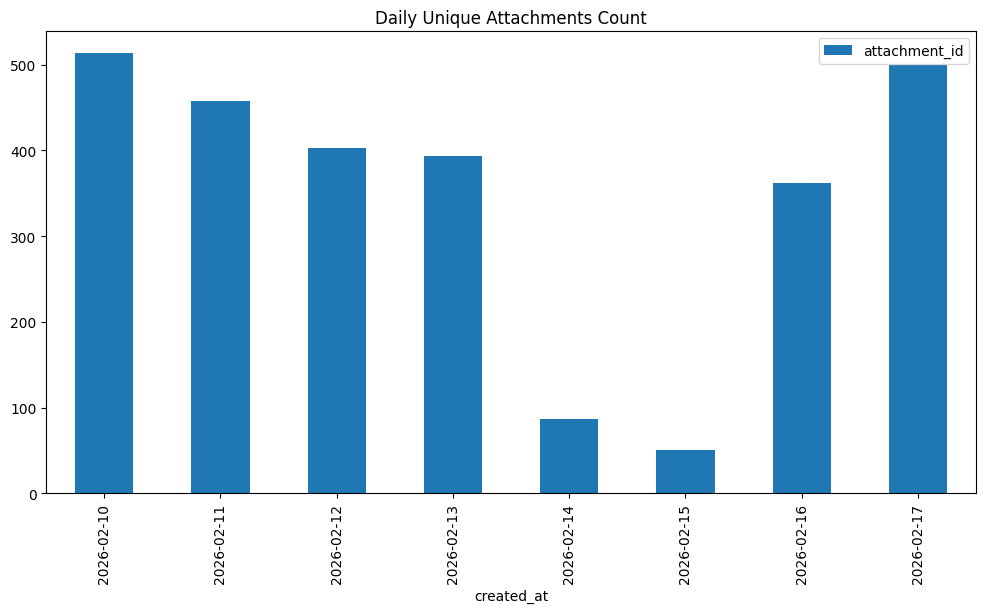

In [57]:
daily_incoming.plot(kind='bar', figsize=(12,6), title='Daily Unique Attachments Count')

In [58]:
# get the predictions for these attachments
attachment_predictions = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_data.attachment_id.unique()])})
""")

In [59]:
egvp_full_data = egvp_data.merge(attachment_predictions, on='attachment_id', how='outer', suffixes=('_attachment', '_prediction'))

In [60]:
egvp_full_data

,id_attachment,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at_attachment,s3_key,s3_bucket,egvp_id,filter,id_prediction,created_at_prediction,model_name,type,subtype,value
0,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157544,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va'
1,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157545,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False'
2,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157546,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.08'
3,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157547,2026-02-10 08:46:46,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
4,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157548,2026-02-10 08:46:46,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18690,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590146,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Valeska Fella'
18691,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590147,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,judicial_summon_date,'20-03-2026'
18692,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590148,2026-02-18 07:19:53,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
18693,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590149,2026-02-18 07:19:53,aftercourt_classificati

In [61]:
egvp_full_data['model_name'].value_counts()

model_name
aftercourt_classification_ladung    9881
aftercourt_classification_pfub      8814
Name: count, dtype: int64

In [62]:
egvp_full_data

,id_attachment,ticket_uuid,attachment_id,zendesk_id,comment_id,status,file_name,file_extension,status_written_at,created_at_attachment,s3_key,s3_bucket,egvp_id,filter,id_prediction,created_at_prediction,model_name,type,subtype,value
0,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157544,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va'
1,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157545,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False'
2,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157546,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.08'
3,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157547,2026-02-10 08:46:46,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
4,3149844,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,NaN,NaN,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new,NRW_B21770698211998c3231d78-eda0-4a14-8e00-325...,False,4157548,2026-02-10 08:46:46,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18690,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590146,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Valeska Fella'
18691,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590147,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,judicial_summon_date,'20-03-2026'
18692,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590148,2026-02-18 07:19:53,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
18693,3188213,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,NaN,NaN,processed,53155892_DR-II_170225_Nachr_Mitlg__an_Glb_uebe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311500/531...,pair-data-engineering-new,NRW_B21771363471665c340c20a-2724-4c8e-b41e-4f8...,False,4590149,2026-02-18 07:19:53,aftercourt_classificati

In [63]:
egvp_full_data.drop_duplicates(subset=['ticket_uuid', 'attachment_id', 'created_at_attachment', 'model_name','type','subtype','value'], inplace=True)

In [64]:
egvp_full_data.shape

(18695, 20)

In [76]:
def is_all_params_extracted(slug, debtor_name, judicial_summon_date):
    if slug and debtor_name and judicial_summon_date and slug != '' and debtor_name != '' and judicial_summon_date != '':
        return True
    return False

unique_attachments = egvp_full_data.attachment_id.unique()

new_daily_df_full_auto = pd.DataFrame({})

for attch_id in unique_attachments:
    attch_pred_data = egvp_full_data[egvp_full_data['attachment_id'] == attch_id]
    ticket_uuid = attch_pred_data['ticket_uuid'].values[0]
    val = attch_pred_data[attch_pred_data['subtype'] == 'is_aftercourt']['value'].values
    if val.size == 0:
        val = attch_pred_data[(attch_pred_data['type'] == 'aftercourt_classification_ladung') & (attch_pred_data['subtype'] == 'class_prob')]['value'].values
        if val.size == 0:
            is_ladung = False
        else:
            try:
                val = val[0]
                val = val.replace("'","")
                val = float(val)
                if val>=0.95:
                    is_ladung=True
                else:
                    is_ladung=False
            except:
                is_ladung=False
            
    else:
        is_ladung = True if "True" in attch_pred_data[attch_pred_data['subtype'] == 'is_aftercourt']['value'].values[0] else False
        
    
    if is_ladung:
        try:
            slug = attch_pred_data[attch_pred_data['subtype'] == 'slug']['value'].values[0]
        except:
            slug = None
        try:
            debtor_name = attch_pred_data[attch_pred_data['subtype'] == 'debtor_name']['value'].values[0]
        except:
            debtor_name = None
        try:
            judicial_summon_date = attch_pred_data[attch_pred_data['subtype'] == 'judicial_summon_date']['value'].values[0]
        except:
            judicial_summon_date = None
        
        all_params_there = is_all_params_extracted(slug, debtor_name, judicial_summon_date)
    else:
        all_params_there = False
        
    
    full_auto_data = {
        'ticket_uuid': ticket_uuid,
        'attachment_id': attch_id,
        'is_ladung': is_ladung,
        'full_auto_confidence': all_params_there,
        'created_at_ticket': pd.to_datetime(attch_pred_data['created_at_attachment'].values[0])
    }
    new_daily_df_full_auto = pd.concat([new_daily_df_full_auto, pd.DataFrame([full_auto_data])], ignore_index=True)

In [77]:
new_daily_df_full_auto

,ticket_uuid,attachment_id,is_ladung,full_auto_confidence,created_at_ticket
0,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383568,False,False,2026-02-10 05:44:00
1,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383569,False,False,2026-02-10 05:44:00
2,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,False,False,2026-02-10 05:44:00
3,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,False,False,2026-02-10 06:44:00
4,350beda5-2f2d-59fa-b4a7-7985638dfd6d,52395088,False,False,2026-02-10 06:44:00
...,...,...,...,...,...
2762,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,True,True,2026-02-17 21:44:00
2763,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,False,False,2026-02-17 21:44:00
2764,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,True,True,2026-02-17 21:44:00
2765,f3841dc5-1260-5292-8660-02899ab84baa,53155889,False,False,2026-02-17 22:44:00


In [78]:
print(new_daily_df_full_auto.ticket_uuid.is_unique, new_daily_df_full_auto.attachment_id.is_unique) # expected false, true

False True


In [79]:
new_daily_df_full_auto['is_automized'] = new_daily_df_full_auto['is_ladung'] & new_daily_df_full_auto['full_auto_confidence']

In [80]:

daily_auto = new_daily_df_full_auto.groupby(new_daily_df_full_auto['created_at_ticket'].dt.date).agg({'is_automized':'sum'})
daily_auto


,is_automized
created_at_ticket,
2026-02-10,107
2026-02-11,74
2026-02-12,69
2026-02-13,75
2026-02-14,16
2026-02-15,17
2026-02-16,72
2026-02-17,94


In [81]:
daily_incoming

,incoming
created_at,
2026-02-10,513
2026-02-11,458
2026-02-12,403
2026-02-13,394
2026-02-14,87
2026-02-15,51
2026-02-16,362
2026-02-17,499


In [82]:
daily_incoming.rename(columns={'attachment_id':'incoming'}, inplace=True)
daily_auto.rename(columns={'is_automized':'automized'}, inplace=True)


In [83]:
stats = daily_incoming.merge(daily_auto, left_index=True, right_index=True, how='outer')
stats

,incoming,automized
created_at,,
2026-02-10,513,107
2026-02-11,458,74
2026-02-12,403,69
2026-02-13,394,75
2026-02-14,87,16
2026-02-15,51,17
2026-02-16,362,72
2026-02-17,499,94


In [84]:
stats['incoming'].sum()

np.int64(2767)

In [85]:
stats['automized'].sum()

np.int64(524)

In [86]:
# Calculate automation percentage
stats['automation_perc'] = (stats['automized'] / stats['incoming']) * 100

# Display summary statistics
print(f"\n{'═' * 60}")
print(f"📊 AUTOMATION SUMMARY")
print(f"{'═' * 60}")
print(f"Total Incoming:           {int(stats['incoming'].sum())}")
print(f"Total Automated:          {int(stats['automized'].sum())}")
print(f"Overall Automation Rate:  {(stats['automized'].sum() / stats['incoming'].sum()) * 100:.2f}%")
print(f"\nMean Daily Automation:    {stats['automation_perc'].mean():.2f}%")
print(f"Min Daily Automation:     {stats['automation_perc'].min():.2f}%")
print(f"Max Daily Automation:     {stats['automation_perc'].max():.2f}%")
print(f"Std Deviation:            {stats['automation_perc'].std():.2f}%")
print(f"Total Days Analyzed:      {len(stats)}")
print(f"{'═' * 60}\n")


════════════════════════════════════════════════════════════
📊 AUTOMATION SUMMARY
════════════════════════════════════════════════════════════
Total Incoming:           2767
Total Automated:          524
Overall Automation Rate:  18.94%

Mean Daily Automation:    20.45%
Min Daily Automation:     16.16%
Max Daily Automation:     33.33%
Std Deviation:            5.41%
Total Days Analyzed:      8
════════════════════════════════════════════════════════════



In [87]:
import plotly.graph_objects as go

# Figure 2: Daily Automation Percentage
fig2 = go.Figure()

fig2.add_trace(
    go.Scatter(
        x=stats.index,
        y=stats['automation_perc'],
        mode='lines+markers',
        name='Automation %',
        line=dict(color='#e74c3c', width=3),
        marker=dict(size=10, line=dict(width=2, color='white')),
        hovertemplate='<b>Date:</b> %{x}<br><b>Automation:</b> %{y:.2f}%<br><extra></extra>'
    )
)

# Add mean line
mean_automation = stats['automation_perc'].mean()
fig2.add_hline(
    y=mean_automation, 
    line_dash="dash", 
    line_color="orange",
    annotation_text=f"Mean: {mean_automation:.2f}%",
    annotation_position="right"
)

fig2.update_layout(
    title=dict(
        text='<b>Daily Automation Percentage</b>',
        font=dict(size=20, family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='<b>Date</b>',
        showgrid=True,
        gridcolor='lightgray',
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title='<b>Percentage (%)</b>',
        showgrid=True,
        gridcolor='lightgray',
        range=[0, 100],
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    height=500,
    margin=dict(l=80, r=80, t=100, b=80)
)

fig2.show()

In [64]:


# Figure 1: Daily Incoming vs Automated Attachments
fig1 = go.Figure()

fig1.add_trace(
    go.Scatter(
        x=stats.index,
        y=stats['incoming'],
        mode='lines+markers',
        name='Incoming',
        line=dict(color='#3498db', width=3),
        marker=dict(size=10, line=dict(width=2, color='white')),
        hovertemplate='<b>Date:</b> %{x}<br><b>Incoming:</b> %{y}<br><extra></extra>'
    )
)

fig1.add_trace(
    go.Scatter(
        x=stats.index,
        y=stats['automized'],
        mode='lines+markers',
        name='Automated',
        line=dict(color='#2ecc71', width=3),
        marker=dict(size=10, line=dict(width=2, color='white')),
        hovertemplate='<b>Date:</b> %{x}<br><b>Automated:</b> %{y}<br><extra></extra>'
    )
)

fig1.update_layout(
    title=dict(
        text='<b>Daily Incoming vs Automated Attachments</b>',
        font=dict(size=20, family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='<b>Date</b>',
        showgrid=True,
        gridcolor='lightgray',
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title='<b>Count</b>',
        showgrid=True,
        gridcolor='lightgray',
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    height=500,
    margin=dict(l=80, r=80, t=100, b=80),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig1.show()

*********

In [65]:
# get attachments given egvp tickets using ticket uuid

egvp_attachments = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments
    WHERE ticket_uuid IN ({', '.join([f"'{uuid}'" for uuid in egvp_data.ticket_uuid.unique()])})
""")


In [66]:
egvp_with_attachments = egvp_data.merge(egvp_attachments, on='ticket_uuid', how='left', suffixes=('_ticket', '_attachment'))

In [68]:
egvp_with_attachments

,id_ticket,ticket_uuid,attachment_id_ticket,zendesk_id_ticket,comment_id_ticket,status_ticket,file_name_ticket,file_extension_ticket,status_written_at_ticket,created_at_ticket,...,attachment_id_attachment,zendesk_id_attachment,comment_id_attachment,status_attachment,file_name_attachment,file_extension_attachment,status_written_at_attachment,created_at_attachment,s3_key_attachment,s3_bucket_attachment
0,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,...,52383571,None,None,rejected_too_long,52383571_VV_38424.pdf,pdf,2026-02-10 07:54:18,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new
1,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,...,52383570,None,None,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new
2,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,...,52383569,None,None,processed,52383569_DR_II_235_26_Information_Kontenabrufe...,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new
3,3149842,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383570,NaN,NaN,processed,52383570_Prot_23526_10022026_053222.pdf,pdf,2026-02-10 08:47:41,2026-02-10 05:44:00,...,52383568,None,None,processed,52383568_Dokument_23526_10022026_053214.pdf,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new
4,3149843,2b1fb49f-62e3-55ec-9c9e-572b901c4381,52383569,NaN,NaN,processed,52383569_DR_II_235_26_Information_Kontenabrufe...,pdf,2026-02-10 08:47:42,2026-02-10 05:44:00,...,52383571,None,None,rejected_too_long,52383571_VV_38424.pdf,pdf,2026-02-10 07:54:18,2026-02-10 05:44:00,ocr_source_files/2026-02-10/egvp_id_306538/523...,pair-data-engineering-new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5809,3188165,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,NaN,NaN,processed,53155829_Dokument_11726_17022026_212946.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,...,53155829,None,None,processed,53155829_Dokument_11726_17022026_212946.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311496/531...,pair-data-engineering-new
5810,3188166,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,NaN,NaN,processed,53155832_Dr_ii_1112_25_aus_schreibmaschine.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,...,53155832,None,None,processed,53155832_Dr_ii_1112_25_aus_schreibmaschine.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311497/531...,pair-data-engineering-new
5811,3188167,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,NaN,NaN,processed,53155835_Dokument_11826_17022026_213736.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,...,53155835,None,None,processed,53155835_Dokument_11826_17022026_213736.pdf,pdf,2026-02-18 07:23:11,2026-02-17 21:44:00,ocr_source_files/2026-02-17/egvp_id_311498/531...,pair-data-engineering-new
5812,3188212,f3841dc5-1260-5292-8660-02899ab84baa,53155889,NaN,NaN,processed,53155889_Dokumente_60926_17022026_204101_signe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,...,53155889,None,None,processed,53155889_Dokumente_60926_17022026_204101_signe...,pdf,2026-02-18 07:23:12,2026-02-17 22:44:00,ocr_source_files/2026-02-17/egvp_id_311499/531...,pair-data-engineering-new


In [70]:
egvp_with_attachments = egvp_with_attachments[['ticket_uuid', 'attachment_id_ticket', 'created_at_ticket', 'status_written_at_ticket','status_attachment']]

In [72]:
egvp_with_attachments.drop_duplicates(['ticket_uuid', 'attachment_id_ticket'], inplace=True)

In [73]:
egvp_with_attachments['status_attachment'].value_counts()

status_attachment
processed            2735
rejected_too_long      32
Name: count, dtype: int64

In [74]:
egvp_with_attachments = egvp_with_attachments[egvp_with_attachments['status_attachment'] == 'processed']

In [76]:
daily_incoming = egvp_with_attachments.groupby(egvp_with_attachments['created_at_ticket'].dt.date).agg({'ticket_uuid':'nunique', 'attachment_id_ticket':'nunique'})

In [77]:
daily_incoming

,ticket_uuid,attachment_id_ticket
created_at_ticket,,
2026-02-10,400,509
2026-02-11,386,453
2026-02-12,316,400
2026-02-13,306,382
2026-02-14,51,87
2026-02-15,44,49
2026-02-16,284,357
2026-02-17,412,498


In [78]:
# Get the predictions

In [79]:
egvp_with_attachments

,ticket_uuid,attachment_id_ticket,created_at_ticket,status_written_at_ticket,status_attachment
12,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed
13,350beda5-2f2d-59fa-b4a7-7985638dfd6d,52395090,2026-02-10 06:44:00,2026-02-10 08:47:42,processed
16,350beda5-2f2d-59fa-b4a7-7985638dfd6d,52395089,2026-02-10 06:44:00,2026-02-10 08:47:42,processed
19,350beda5-2f2d-59fa-b4a7-7985638dfd6d,52395088,2026-02-10 06:44:00,2026-02-10 08:47:42,processed
22,f3b13c1f-2967-5bb6-983b-02f6b276310a,52395097,2026-02-10 06:44:00,2026-02-10 08:47:43,processed
...,...,...,...,...,...
5809,ca02868b-8d5a-553f-ab4a-ea51984b74a0,53155829,2026-02-17 21:44:00,2026-02-18 07:23:11,processed
5810,5a518a5a-c5f4-512f-9e0a-bb8d742f9a4d,53155832,2026-02-17 21:44:00,2026-02-18 07:23:11,processed
5811,09f2a1f9-48db-55c2-a2d9-00e93404c2b2,53155835,2026-02-17 21:44:00,2026-02-18 07:23:11,processed
5812,f3841dc5-1260-5292-8660-02899ab84baa,53155889,2026-02-17 22:44:00,2026-02-18 07:23:12,processed


In [81]:
# get the predictions for these attachments
attachment_predictions = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions
    WHERE attachment_id IN ({', '.join([f"'{att_id}'" for att_id in egvp_with_attachments.attachment_id_ticket.unique()])})
""")

In [89]:
egvp_with_attachments.rename(columns={'attachment_id_ticket':'attachment_id'}, inplace=True)

In [91]:
egvp_full_data = egvp_with_attachments.merge(attachment_predictions, on='attachment_id', how='outer', suffixes=('_attachment', '_prediction'))

In [92]:
egvp_full_data

,ticket_uuid,attachment_id,created_at_ticket,status_written_at_ticket,status_attachment,id,created_at,model_name,type,subtype,value
0,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed,4157550,2026-02-10 08:46:46,aftercourt_classification_ladung,aftercourt_classification_ladung,aftercourt_type,'ladung_va'
1,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed,4157551,2026-02-10 08:46:47,aftercourt_classification_ladung,aftercourt_classification_ladung,class_pred,'False'
2,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed,4157552,2026-02-10 08:46:47,aftercourt_classification_ladung,aftercourt_classification_ladung,class_prob,'0.38'
3,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed,4157553,2026-02-10 08:46:47,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
4,a8445dc0-dbeb-595e-b6b5-2cca3ee967e7,52395079,2026-02-10 06:44:00,2026-02-10 08:47:42,processed,4157554,2026-02-10 08:46:47,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'
...,...,...,...,...,...,...,...,...,...,...,...
18496,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,2026-02-17 22:44:00,2026-02-18 07:23:12,processed,4590146,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,debtor_name,'Valeska Fella'
18497,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,2026-02-17 22:44:00,2026-02-18 07:23:12,processed,4590147,2026-02-18 07:19:53,aftercourt_classification_ladung,aftercourt_classification_ladung,judicial_summon_date,'20-03-2026'
18498,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,2026-02-17 22:44:00,2026-02-18 07:23:12,processed,4590148,2026-02-18 07:19:53,aftercourt_classification_pfub,aftercourt_classification_pfub,aftercourt_type,'pfub_erlass'
18499,dd21ee10-d2e4-5cdf-afb7-a697c9f475e5,53155892,2026-02-17 22:44:00,2026-02-18 07:23:12,processed,4590149,2026-02-18 07:19:53,aftercourt_classification_pfub,aftercourt_classification_pfub,class_pred,'False'


In [93]:
egvp_full_data['model_name'].value_counts()

model_name
aftercourt_classification_ladung    9785
aftercourt_classification_pfub      8716
Name: count, dtype: int64

In [94]:
total = egvp_full_data

In [95]:
egvp_full_data = egvp_full_data[egvp_full_data['model_name'] == 'aftercourt_classification']

In [96]:
egvp_full_data.reset_index(drop=True, inplace=True)

In [97]:
egvp_full_data

,ticket_uuid,attachment_id,created_at_ticket,status_written_at_ticket,status_attachment,id,created_at,model_name,type,subtype,value


In [98]:
egvp_full_data['model_name'].value_counts()

Series([], Name: count, dtype: int64)

In [99]:
egvp_full_data['subtype'].value_counts()

Series([], Name: count, dtype: int64)

In [100]:
egvp_full_data.shape

(0, 11)

In [101]:
egvp_full_data.drop(columns=['id'], inplace=True, axis=1)

/var/folders/ym/hcyz4chn3cq4n_8dslg5k50h0000gn/T/ipykernel_83605/1343409744.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [102]:
egvp_full_data

,ticket_uuid,attachment_id,created_at_ticket,status_written_at_ticket,status_attachment,created_at,model_name,type,subtype,value


In [103]:
egvp_full_data.drop_duplicates(subset=['ticket_uuid', 'attachment_id', 'created_at_ticket', 'model_name','type','subtype','value'], inplace=True)

,ticket_uuid,attachment_id,created_at_ticket,status_written_at_ticket,status_attachment,created_at,model_name,type,subtype,value


In [104]:
egvp_full_data.shape

(0, 10)

### Daily full automation percentage

In [105]:
def is_all_params_extracted(slug, debtor_name, judicial_summon_date):
    if slug and debtor_name and judicial_summon_date and slug != '' and debtor_name != '' and judicial_summon_date != '':
        return True
    return False

unique_attachments = egvp_full_data.attachment_id.unique()

new_daily_df_full_auto = pd.DataFrame({})

for attch_id in unique_attachments:
    attch_pred_data = egvp_full_data[egvp_full_data['attachment_id'] == attch_id]
    ticket_uuid = attch_pred_data['ticket_uuid'].values[0]
    is_ladung = True if "True" in attch_pred_data[attch_pred_data['subtype'] == 'is_aftercourt']['value'].values[0] else False
    
    if is_ladung:
        try:
            slug = attch_pred_data[attch_pred_data['subtype'] == 'slug']['value'].values[0]
        except:
            slug = None
        try:
            debtor_name = attch_pred_data[attch_pred_data['subtype'] == 'debtor_name']['value'].values[0]
        except:
            debtor_name = None
        try:
            judicial_summon_date = attch_pred_data[attch_pred_data['subtype'] == 'judicial_summon_date']['value'].values[0]
        except:
            judicial_summon_date = None
        
        all_params_there = is_all_params_extracted(slug, debtor_name, judicial_summon_date)
    else:
        all_params_there = False
        
    
    full_auto_data = {
        'ticket_uuid': ticket_uuid,
        'attachment_id': attch_id,
        'is_ladung': is_ladung,
        'full_auto_confidence': all_params_there,
        'created_at_ticket': pd.to_datetime(attch_pred_data['created_at_ticket'].values[0])
    }
    new_daily_df_full_auto = pd.concat([new_daily_df_full_auto, pd.DataFrame([full_auto_data])], ignore_index=True)

In [108]:
new_daily_df_full_auto

""


In [107]:
print(new_daily_df_full_auto.ticket_uuid.is_unique, new_daily_df_full_auto.attachment_id.is_unique) # expected false, true

AttributeError: 'DataFrame' object has no attribute 'ticket_uuid'

In [ ]:
# statistics 1: In one day, how many tickets we are getting and how many of them are ladung
daily_incoming = new_daily_df_full_auto.groupby(new_daily_df_full_auto['created_at_ticket'].dt.date).agg({'ticket_uuid':'nunique', 'attachment_id':'nunique'})
daily_incoming.rename(columns={'ticket_uuid':'num_tickets', 'attachment_id':'num_attachments'}, inplace=True)
daily_incoming

In [ ]:
# statistics 2: In one day, how many ladung attachments are fully auto processed
daily_fully_auto = new_daily_df_full_auto[new_daily_df_full_auto['is_ladung'] == True].groupby(new_daily_df_full_auto['created_at_ticket'].dt.date).agg({'attachment_id':'nunique', 'full_auto_confidence': 'sum'})
daily_fully_auto.rename(columns={'attachment_id':'num_ladung_attachments', 'full_auto_confidence':'num_fully_auto'}, inplace=True)

# Also count non-ladung attachments
daily_non_ladung = new_daily_df_full_auto[new_daily_df_full_auto['is_ladung'] == False].groupby(new_daily_df_full_auto['created_at_ticket'].dt.date).agg({'attachment_id':'nunique'})
daily_non_ladung.rename(columns={'attachment_id':'num_non_ladung_attachments'}, inplace=True)

# Merge the two dataframes and add total attachments from daily_incoming
daily_fully_auto = daily_fully_auto.merge(daily_non_ladung, left_index=True, right_index=True, how='outer').fillna(0)
daily_fully_auto = daily_fully_auto.merge(daily_incoming[['num_attachments']], left_index=True, right_index=True, how='left')
daily_fully_auto.rename(columns={'num_attachments': 'total_attachments'}, inplace=True)
daily_fully_auto


In [ ]:
# statistics 3: Number of fully automated tickets per day
# A ticket is considered fully automated if it has at least one attachment with full_auto_confidence=True
daily_automated_tickets = new_daily_df_full_auto[new_daily_df_full_auto['full_auto_confidence'] == True].groupby(
    new_daily_df_full_auto['created_at_ticket'].dt.date
).agg({'ticket_uuid': 'nunique'})
daily_automated_tickets.rename(columns={'ticket_uuid': 'num_fully_automated_tickets'}, inplace=True)

# Merge with daily_fully_auto to get all statistics together
daily_stats = daily_fully_auto.merge(daily_automated_tickets, left_index=True, right_index=True, how='left').fillna(0)

# Add number of incoming tickets per day from daily_incoming
daily_stats = daily_stats.merge(daily_incoming[['num_tickets']], left_index=True, right_index=True, how='left')
daily_stats.rename(columns={'num_tickets': 'total_tickets'}, inplace=True)

daily_stats

In [ ]:
# Calculate percentage of automated tickets per day
daily_stats['ticket_automation_perc'] = (daily_stats['num_fully_automated_tickets'] / daily_stats['total_tickets']) * 100

# Create visualization for ticket automation percentage
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=daily_stats.index,
    y=daily_stats['ticket_automation_perc'],
    mode='lines+markers',
    name='Ticket Automation %',
    line=dict(color='#2ecc71', width=3),
    marker=dict(size=10, line=dict(width=2, color='white')),
    hovertemplate='<b>Date:</b> %{x}<br><b>Automation:</b> %{y:.2f}%<br><extra></extra>'
))

# Add mean line
mean_ticket_automation = daily_stats['ticket_automation_perc'].mean()
fig.add_hline(
    y=mean_ticket_automation, 
    line_dash="dash", 
    line_color="red",
    annotation_text=f"Mean: {mean_ticket_automation:.2f}%",
    annotation_position="right"
)

# Update layout
fig.update_layout(
    title=dict(
        text='<b>Daily Ticket Automation Percentage</b><br><sub>Percentage of Tickets that is Fully Automated  as Ladung (All params are extracted)</sub>',
        font=dict(size=20, family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title='<b>Date</b>',
        showgrid=True,
        gridcolor='lightgray',
        tickformat='%Y-%m-%d',
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title='<b>Automation Percentage (%)</b>',
        showgrid=True,
        gridcolor='lightgray',
        range=[0, 100],
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified',
    height=550,
    margin=dict(l=80, r=80, t=120, b=80)
)

fig.show()

# Display summary statistics
print(f"\n{'═' * 60}")
print(f"📊 TICKET AUTOMATION SUMMARY")
print(f"{'═' * 60}")
print(f"Mean Automation Rate:     {mean_ticket_automation:.2f}%")
print(f"Min Automation Rate:      {daily_stats['ticket_automation_perc'].min():.2f}%")
print(f"Max Automation Rate:      {daily_stats['ticket_automation_perc'].max():.2f}%")
print(f"Std Deviation:            {daily_stats['ticket_automation_perc'].std():.2f}%")
print(f"Total Days Analyzed:      {len(daily_stats)}")
print(f"\nTotal Tickets:            {int(daily_stats['total_tickets'].sum())}")
print(f"Fully Automated Tickets:  {int(daily_stats['num_fully_automated_tickets'].sum())}")
print(f"Overall Automation Rate:  {(daily_stats['num_fully_automated_tickets'].sum() / daily_stats['total_tickets'].sum()) * 100:.2f}%")
print(f"{'═' * 60}\n")